In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import time
import copy
import tomlkit
import importlib

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle, Circle
from matplotlib.ticker import FormatStrFormatter

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import cupy as cp
cp.cuda.Device(7).use()

import warnings
warnings.filterwarnings("ignore")

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, rt_utils

import esc_llowfsc_sim
from esc_llowfsc_sim import source_flux
import esc_llowfsc_sim.esc_fraunhofer as esc

from magpyx.utils import ImageStream

model_path = esc_llowfsc_sim.path/'data/2k-256/'
# model_path = esc_llowfsc_sim.path/'data/1k-256/'

with open(model_path/'model_params.toml', mode="r",) as fp:
    all_params = tomlkit.load(fp).unwrap()
    
model_params = all_params['model']
wfe_params = all_params['wfe']
camlo_params = all_params['camlo']
camsci_params = all_params['camsci']

/opt/conda/envs/llowfscSim310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import pylablib. NKT laser functionality not available.


Total flux over bandpass = 9.273e+09 ph / (s m2)


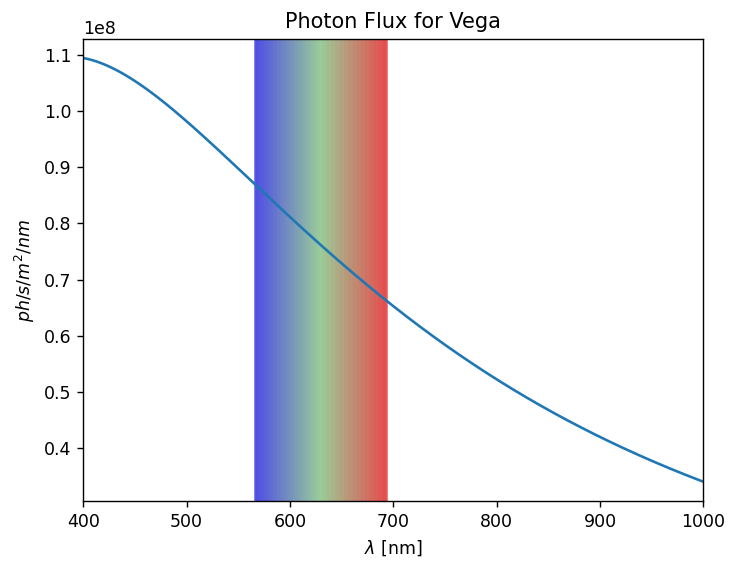

In [2]:
Nwaves = 101
bw = 0.20
waves = np.linspace(model_params['wavelength_c']*(1 - bw/2), model_params['wavelength_c']*(1 + bw/2), Nwaves)

mag0_source_params = source_flux.mag0_source_params
mag0_source_params.update({'wavelengths':waves})
mag0_source = source_flux.SOURCE(**mag0_source_params)
mag0_source.plot_spectrum_ph()
mag0_flux_per_wave = mag0_source.calc_fluxes()
mag0_total_ep_flux = np.sum(mag0_flux_per_wave)
print(f'Total flux over bandpass = {mag0_total_ep_flux:.3e}')

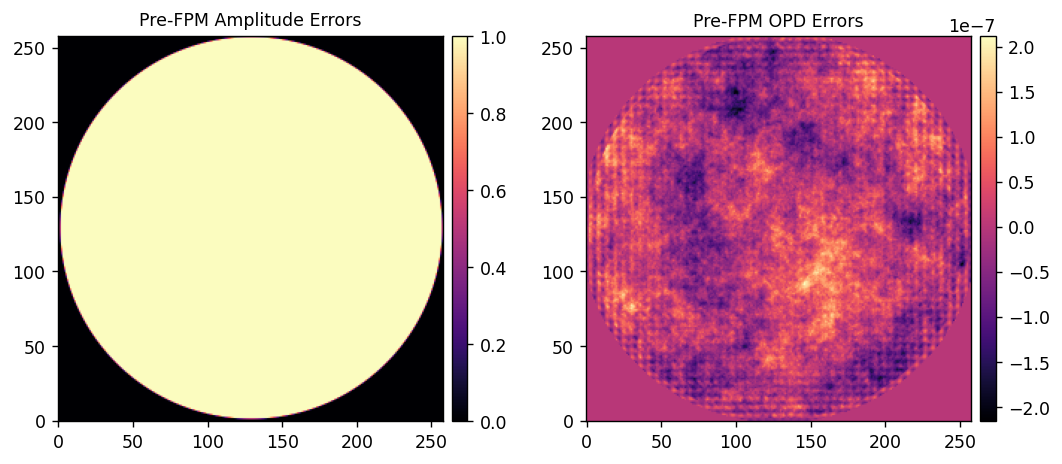

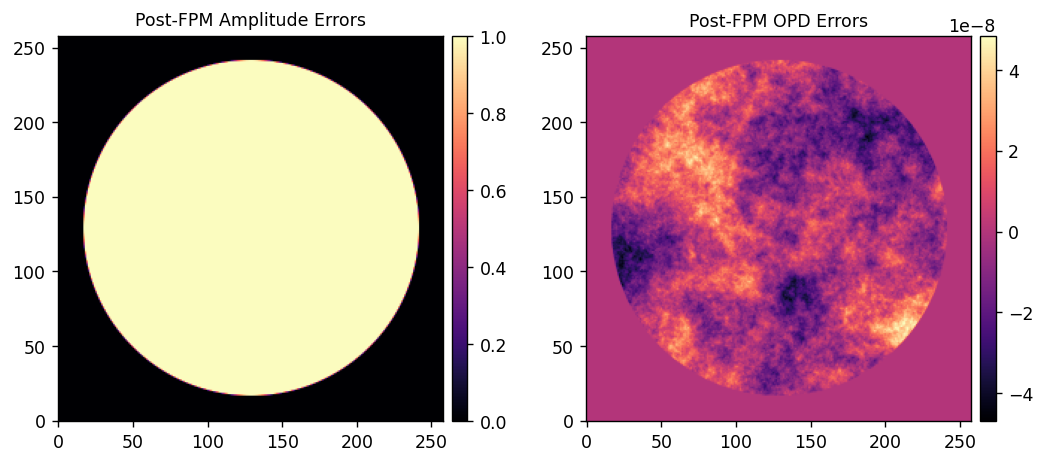

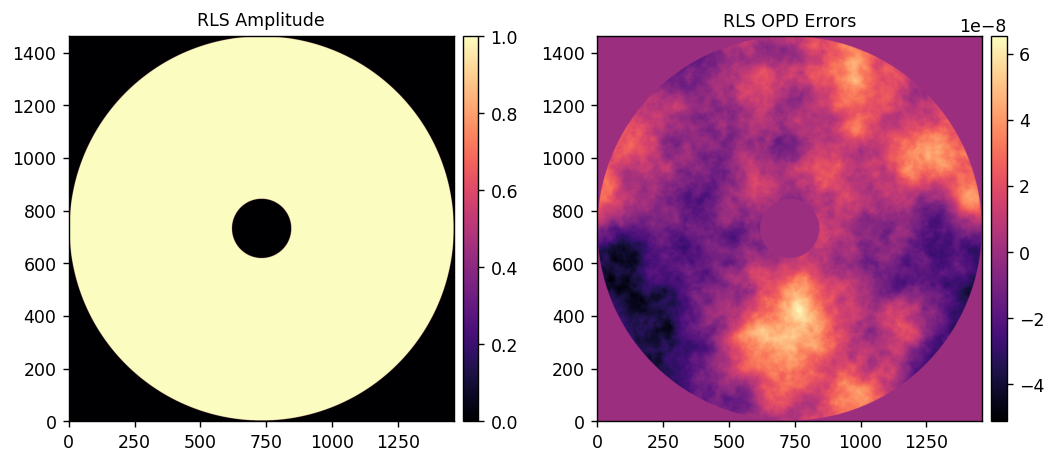

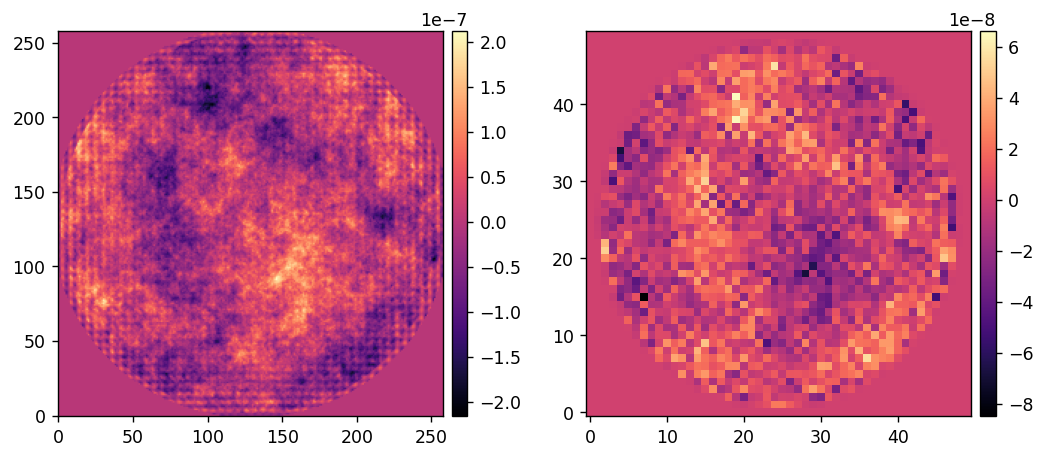

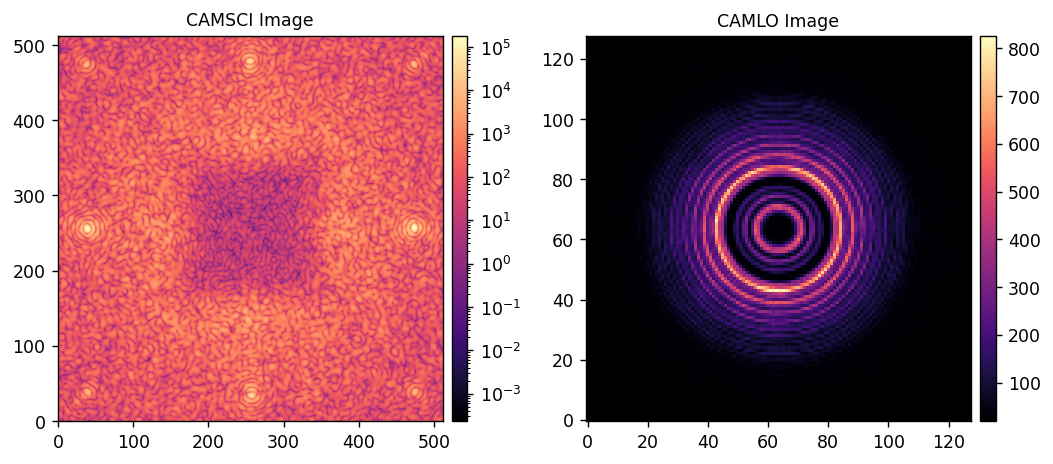

In [3]:
reload(esc)

# Update some model parameters if desired
model_params.update({
    'ncamlo':128,
    'ncamsci':512,
    # 'llowfsc_defocus':0e-3,
})

# Update some WFE parameters if desired
wfe_params.update({
    'dm_astig_rms':0e-9,
    'compute_flat':True,
    'plot_flat':True,
})

M = esc.single(
    **model_params,
    entrance_flux=mag0_total_ep_flux,
)
M.init_wfe(**wfe_params)
PREFPM_OPD0 = copy.copy(M.PREFPM_OPD)
POSTFPM_OPD0 = copy.copy(M.POSTFPM_OPD)

# Use the CAMLO detector model
camlo_module = importlib.import_module(camlo_params['module'])
camlo_cls = getattr(camlo_module, camlo_params['type'])
CAMLO = camlo_cls(**camlo_params['params'])
M.CAMLO = CAMLO

# Use the CAMSCI detector model
camsci_module = importlib.import_module(camsci_params['module'])
camsci_cls = getattr(camsci_module, camsci_params['type'])
CAMSCI = camsci_cls(**camsci_params['params'])
# M.CAMSCI = CAMSCI

M.use_vortex = 1
camsci_im, camlo_im = M.snap_camsci_and_camlo()

utils.imshow(
    [camsci_im, camlo_im],
    titles=['CAMSCI Image', 'CAMLO Image'],
    norms=[LogNorm()],
)



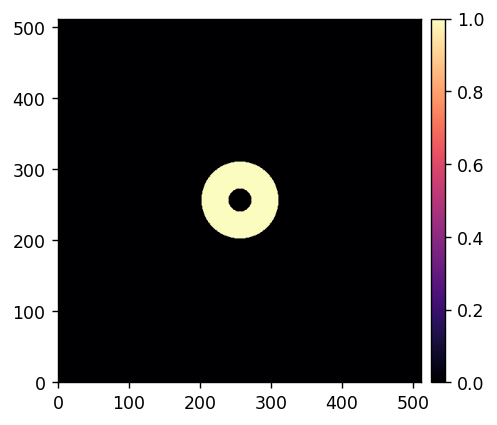

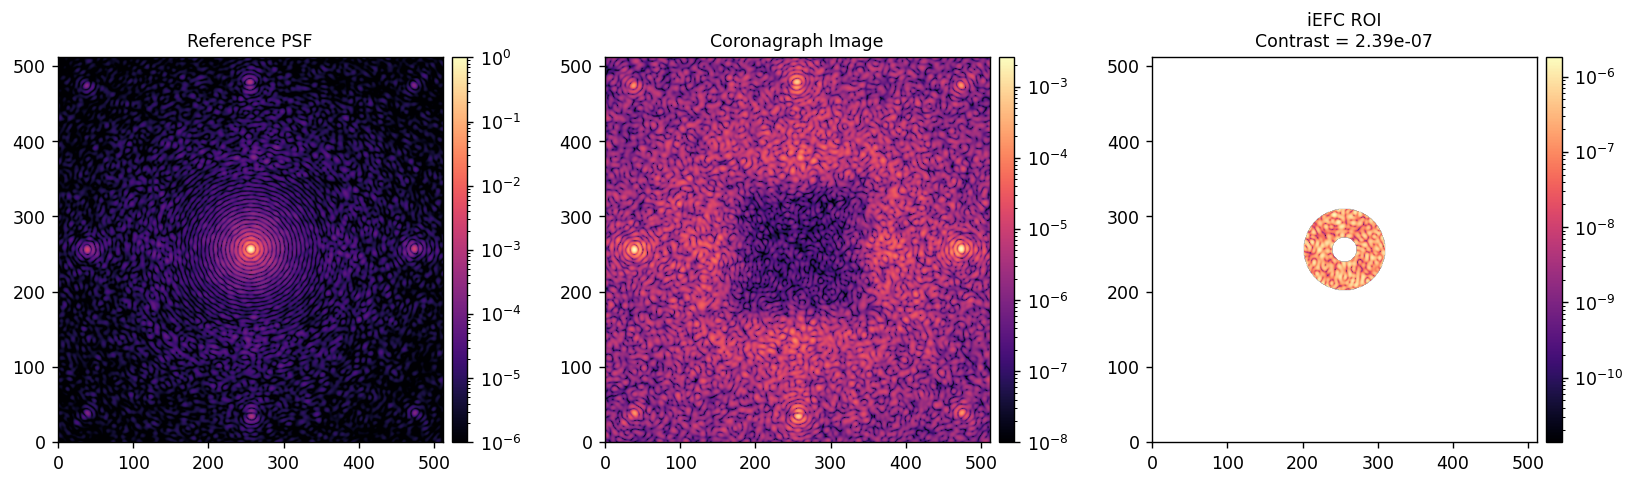

In [4]:
M.reset_dm()
# M.zero_dm(0)

M.Imax_ref = 1
M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
coro_im = M.snap_camsci()

iwa, owa = (3, 10)
wfs_mask = utils.create_annular_mask(
    M.ncamsci, 
    iwa, 
    owa, 
    M.camsci_pxscl_lamDc, 
    # edge=iwa, 
    # rotation=90, 
    plot=1,
    # return_np=1,
)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [ref_psf/M.Imax_ref, coro_im, coro_im * wfs_mask],
    norms=[LogNorm(1e-6), LogNorm(1e-8), LogNorm()],
    titles=['Reference PSF', 'Coronagraph Image', f'iEFC ROI\nContrast = {contrast:.2e}']
    # cmaps=['magma'],
)

# Create and connect to the shmims necessary for the RT simulator. 

In [10]:
# rt_utils.create_shmim('camsci', (M.ncamsci, M.ncamsci))
# rt_utils.change_shmim_permissions('camsci', 'kianmilani', target_group='magaox')
rt_utils.create_shmim('camlo2', (M.ncamlo, M.ncamlo))
rt_utils.change_shmim_permissions('camlo2', 'kianmilani', target_group='magaox')
# rt_utils.create_shmim('camlosim-avg', (M.ncamlo, M.ncamlo))
# rt_utils.change_shmim_permissions('camlosim-avg', 'kianmilani', target_group='magaox')
rt_utils.create_shmim('opdsim', (10, 1))
# rt_utils.create_shmim('fsm01', (2, 1))
# rt_utils.create_shmim('fsm02', (2, 1))
rt_utils.create_shmim('ncamlo', (1,1))
rt_utils.create_shmim('camscishutter', (1,1))
rt_utils.create_shmim('camsciexptime', (1,1))
rt_utils.create_shmim('camscigain', (1,1))
rt_utils.create_shmim('camloshutter', (1,1))
rt_utils.create_shmim('camloexptime', (1,1))
rt_utils.create_shmim('camlogain', (1,1))
rt_utils.create_shmim('vmag', (1,1))
rt_utils.create_shmim('usevortex', (1,1))

CAMSCI_STREAM = ImageStream('camsci')
CAMSCI_SHUTTER_STREAM = ImageStream('camscishutter')
CAMSCI_EXPTIME_STREAM = ImageStream('camsciexptime')
CAMSCI_GAIN_STREAM = ImageStream('camscigain')
CAMLO_STREAM = ImageStream('camlo2')
CAMLO_SHUTTER_STREAM = ImageStream('camloshutter')
CAMLO_EXPTIME_STREAM = ImageStream('camloexptime')
CAMLO_GAIN_STREAM = ImageStream('camlogain')
VMAG_STREAM = ImageStream('vmag')
OPD_STREAM = ImageStream('opdsim')
USEVORTEX_STREAM = ImageStream('usevortex')

fsm_ind = '00'
FSM_STREAMS = []
for i in range(12):
    FSM_STREAMS.append(ImageStream(f'dm{fsm_ind}disp{i:02}'))
FSMT_STREAM = ImageStream(f'dm{fsm_ind}disp')

dm_ind = '02'
DM_STREAMS = []
for i in range(12):
    DM_STREAMS.append(ImageStream(f'dm{dm_ind}disp{i:02}'))
DMT_STREAM = ImageStream(f'dm{dm_ind}disp')

if M.CAMSCI is not None:
    CAMSCI_EXPTIME_STREAM.write(np.array([[M.CAMSCI.exp_time]]))
if M.CAMLO is not None:
    CAMLO_EXPTIME_STREAM.write(np.array([[M.CAMLO.exp_time]]))

rt_utils.zero(DM_STREAMS)
DM_STREAMS[0].write(ensure_np_array(M.dm_flat) * 1e6 )
rt_utils.write(USEVORTEX_STREAM, [1])


# Define the function to compute and write images to shmims in real time. 

In [14]:

M.NCAMSCI = 1
M.NCAMLO = 1
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=10, remove_modes=1)

def rt_snap():
    vmag = VMAG_STREAM.grab_latest()[0,0]
    M.flux_scale_factor = 2.512**(-vmag)
    M.use_vortex = USEVORTEX_STREAM.grab_latest()[0,0]>0.5
    
    wfe_coeff = OPD_STREAM.grab_latest()[0]
    wfe_opd = xp.sum( xp.array(wfe_coeff[:, None, None]) * wfe_modes, axis=0)
    M.set_prefpm_wfe(PREFPM_OPD0 + wfe_opd)
    
    fsm_command = FSMT_STREAM.grab_latest()[0][:2]
    M.set_fsm(xp.array(fsm_command), RMS=1)

    total_dm_command = DMT_STREAM.grab_latest()
    M.set_dm(xp.array(total_dm_command)/1e6, channel=0)
    
    if M.CAMSCI is not None:
        M.camsci_shutter = CAMSCI_SHUTTER_STREAM.grab_latest()[0,0]>0.5
        M.CAMSCI.exp_time = CAMSCI_EXPTIME_STREAM.grab_latest()[0,0]
        M.CAMSCI.gain = CAMSCI_GAIN_STREAM.grab_latest()[0,0]

    if M.CAMLO is not None:
        M.camlo_shutter = CAMLO_SHUTTER_STREAM.grab_latest()[0,0]>0.5
        M.CAMLO.exp_time = CAMLO_EXPTIME_STREAM.grab_latest()[0,0]
        M.CAMLO.gain = CAMLO_GAIN_STREAM.grab_latest()[0,0]

    camsci_im, camlo_im = M.snap_camsci_and_camlo()
    
    CAMSCI_STREAM.write(ensure_np_array(camsci_im))
    CAMLO_STREAM.write(ensure_np_array(camlo_im))

In [8]:
%%timeit -n 200
snap()

6.04 ms ± 223 μs per loop (mean ± std. dev. of 7 runs, 200 loops each)


# Run the simulator in a while-loop. This can be paused by a keyboard interrupt (whatever that shortcut happens to be for you).

In [15]:
cam_freq = 100.0
CYCLETIME = 1/cam_freq

fun_times = []

try:
    print('Running CAMLO simulator continuously ...')
    
    t0 = time.perf_counter()  # Time ref point
    time_counter = 0.0
    
    while 1:
        rt_snap()
        fun_times.append(time.time())
        
        now = time.perf_counter()
        elapsed_time = now - t0
        target_time = time_counter + CYCLETIME
        if elapsed_time < target_time:
            time.sleep(target_time - elapsed_time)

        time_counter += CYCLETIME
except KeyboardInterrupt:
    fun_times = np.array(fun_times)
    print('CAMLO simulator terminated.')

Running CAMLO simulator continuously ...
CAMLO simulator terminated.


### Check the frame times from when the model was running. Note that the timing can be more inconsisitent if other process are using the same machine. Even though the model runs on a GPU, the CPU usage still affects the timing (not sure why exactly). 

(0.0099949595378816, 100.05043004025475)

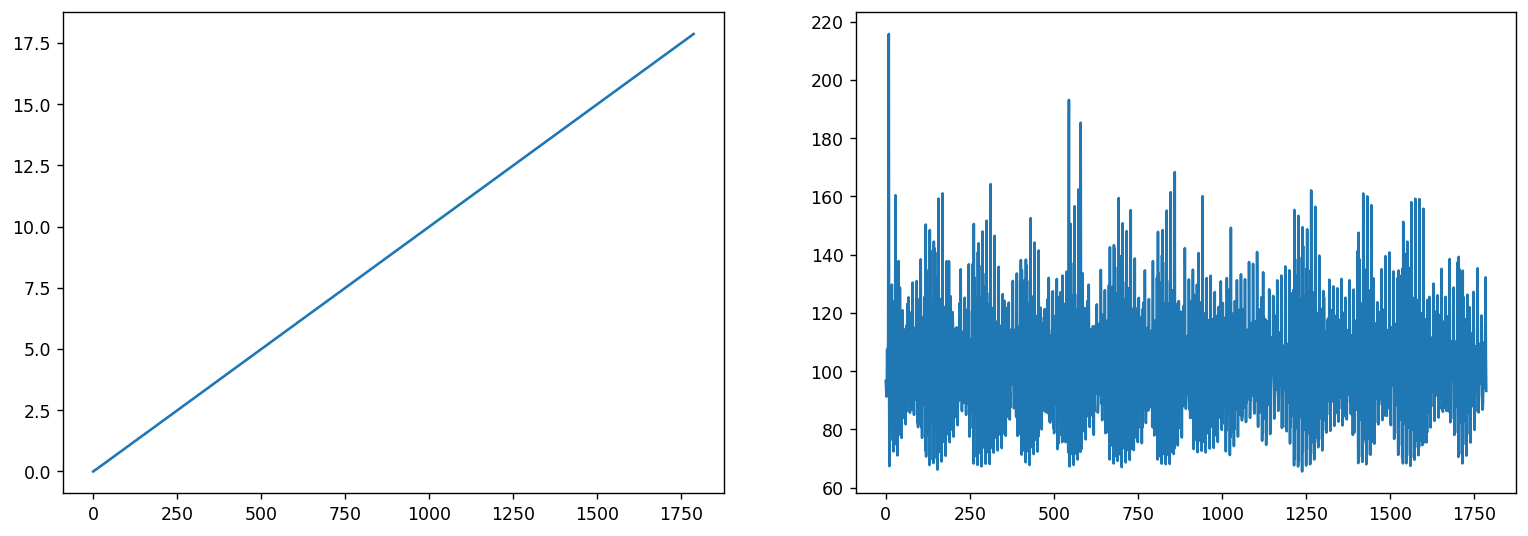

In [13]:

fun_times -= fun_times[0]
del_fun_times = fun_times[1:] - fun_times[:-1]
freqs = 1/del_fun_times
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=125, figsize=(15,5))
axs[0].plot(fun_times)
axs[1].plot(freqs)
np.mean(del_fun_times), 1/np.mean(del_fun_times)

# Run the model continuously using a thread. This does not seem to work very well as framerates can be more inconsistent this way. I tried using multiprocessing instead but that has trouble using CuPy. 

In [25]:
from lina import rt_utils
reload(rt_utils)

cam_thread = rt_utils.TimedThread(
    1/500,
    snap,
)

In [26]:
cam_thread.start()

In [27]:
cam_thread.stop()


Thread stopped.
